Smoothing and Time Smoothing

<frozen importlib._bootstrap>:241: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


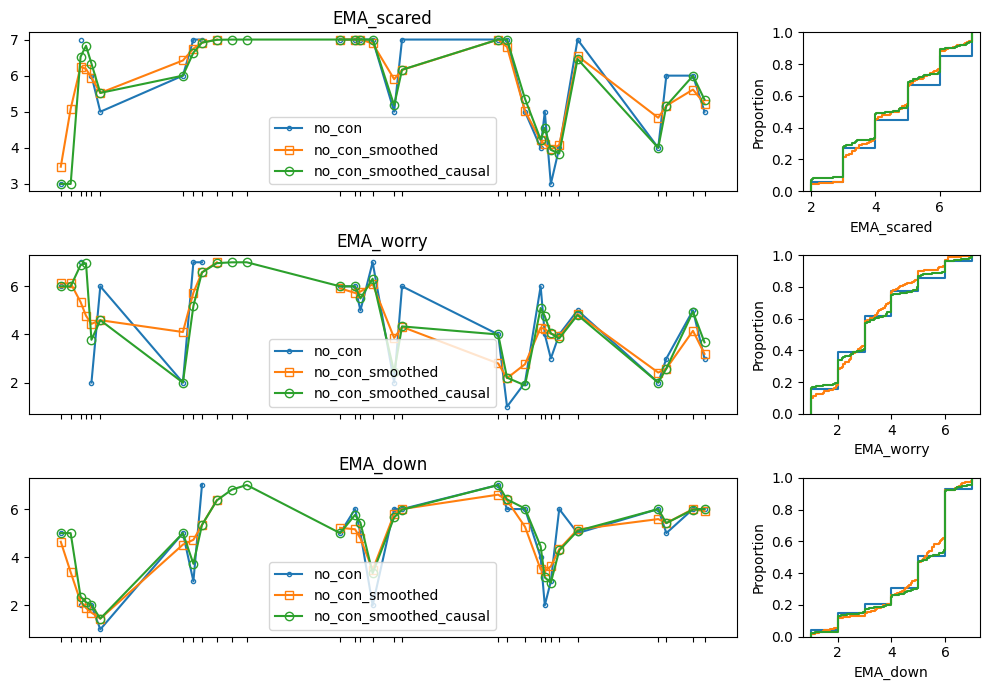

In [1]:
import os
import sys
sys.path.append('..')
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import data_utils
from feature_names import NON_CONDITIONAL_FEAT
from main_preprocessing import preprocessing_pipeline

preprocessing_pipelines = ['no_con', 'no_con_smoothed', 'no_con_smoothed_causal']


main_dir = '/home/janik.fechtelpeter/Documents/reallaborai4u/data_management'
MRT = 1
participant = 14
features = NON_CONDITIONAL_FEAT[2:5]
show_max_deviation_of_smoothing_methods = True
x_axis = 'DateTime'
window_size = 30

raw_data_path = os.path.join(data_utils.single_subject_path(MRT, 'raw', participant))
raw_data = pd.read_json(raw_data_path)

data = []
for i, pp in enumerate(preprocessing_pipelines):
    data.append(preprocessing_pipeline(raw_data, pp))
    data[i].reset_index(inplace=True)

if show_max_deviation_of_smoothing_methods:
    deviation = data[1][features] - data[0][features]
    window = deviation.rolling(window_size).sum().sum(axis=1).argmax()
else:
    window = 0

n_feat = len(features)
fig, axes = plt.subplots(n_feat, 2, figsize=(10,1+2*n_feat), gridspec_kw={'width_ratios': [4, 1]})
markers = ['.', 's', 'o', 'v']
for j, f in enumerate(features):
    for i, df in enumerate(data):
        axes[j,0].plot(df[x_axis].iloc[window : window+window_size], 
                    df[f].iloc[window : window+window_size], 
                    marker=markers[i], label=preprocessing_pipelines[i], 
                    fillstyle='none')
        sns.ecdfplot(df[f], ax=axes[j,1])
    axes[j,0].set_xticks(df[x_axis].iloc[window : window+window_size])
    plt.setp(axes[j,0].get_xticklabels(), visible=False)
    axes[j,0].legend()
    axes[j,0].set_title(f)
fig.tight_layout()

Box-cox transform

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import pandas as pd
from preprocessing_pipeline import preprocessing_pipeline
from feature_names import OBSERVATION_FEAT

main_dir = '/home/janik.fechtelpeter/Documents/reallaborai4u/data_management'
participant = 14
features = OBSERVATION_FEAT
show_max_deviation_of_transformation = False
window_size = 30

raw_data_path = os.path.join(main_dir, 'raw', f'11228_{participant}.json')
raw_data = pd.read_json(raw_data_path)
time_smoothed_data, _ = preprocessing_pipeline(raw_data, merge_consolidation=True, bin=True, 
                                           smooth=True, impute=False, encode_missing_emas=False, smoothing_type='equal', zscore=True)
boxcox_data, _ = preprocessing_pipeline(raw_data, merge_consolidation=True, bin=True, 
                                           smooth=True, impute=False, encode_missing_emas=False, smoothing_type='equal', boxcox=True, zscore=True)
if isinstance(features[0], int):
    features = [OBSERVATION_FEAT[f] for f in features]
if show_max_deviation_of_transformation:
    deviation = time_smoothed_data[features] - boxcox_data[features]
    window = deviation.rolling(window_size).sum().sum(axis=1).argmax()
else:
    window = 0
n_feat = len(features)
fig, axes = plt.subplots(n_feat, 1, figsize=(4,1+3.5*n_feat))
for j, f in enumerate(features):
    sns.ecdfplot(time_smoothed_data[f], ax=axes[j], label='regular')
    sns.ecdfplot(boxcox_data[f], ax=axes[j], label='boxcox')
    space = np.linspace(*axes[j].get_xlim(), 100)
    axes[j].plot(space, stats.norm.cdf(space), label='gaussian')
    axes[j].set_title(f)
    axes[j].legend()

fig.tight_layout()

<frozen importlib._bootstrap>:241: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


ModuleNotFoundError: No module named 'preprocessing_pipeline'